In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [101]:
performance = pd.read_csv("performance.tsv", sep="\t")

identity0 = pd.read_csv("identity_card_0.tsv", sep="\t")
identity1 = pd.read_csv("identity_card_1.csv")

medical_raw = pd.read_excel("medical_information.xlsx", header=None)

moms = pd.read_json("moms_notes.json")

scouting = pd.read_csv("hockey_scouting_notes.csv")

missing_links_raw=pd.read_csv("missing_link.csv")

with open("contracts_competition.pkl", "rb") as f:
    contracts = pickle.load(f)

In [102]:
identity0 = identity0.rename(columns={
    "numerus_internationalis_ad_identitatem": "international_id",
    "numerus_identificationis_ad_medicinam": "medical_id",
    "praenomen": "first_name",
    "cognomen": "last_name",
    "sexus": "gender",
    "aetas_annorum": "age",
    "urbs_natalis": "birth_city",
    "natio": "nationality"
})

def roman_to_int(number):
    roman = { "I": 1, "V": 5, "X": 10, "L": 50, "C": 100, "D": 500, "M": 1000 }

    result = 0
    prev = 0

    for char in reversed(str(number).upper()):
        value = roman.get(char, 0)

        if value < prev:
            result -= value
        else:
            result += value
        prev = value

    return result

identity0["international_id"] = identity0["international_id"].apply(roman_to_int)

identity = pd.concat([identity0, identity1], ignore_index=True)
identity.head()

,international_id,medical_id,first_name,last_name,gender,age,birth_city,nationality
0,275,039e0ab7-e36d-4bc7-a0b1-3e93e8ec73e9,Keithus,Alleeius,male,23.0,vienna,austria
1,2560,070dfb40-76c9-4894-90e5-7463d060d49b,Alyssa,Kohlius,f,31.0,Vienna,austria
2,2323,fa06ed07-6f09-4ec2-9f11-a70917307270,Emily,Belangerius,female,29.0,OSTRAVA,france
3,7708,59f94605-e953-4117-b9ee-09ba1392e895,Stefanie,Fiedlerius,female,25.0,rome,italy
4,4062,2e663575-2f96-42fc-ab59-481993a65a53,Melanie,Mulliganius,female,312.0,Paris,france


In [103]:
medical = medical_raw.copy()

medical.columns = [
    "medical_id",
    "height",
    "weight",
    "age_in_years",
    "shoe_size",
    "body_fat_percentage",
    "fitness_level",
    "sprint_time",
    "medical_information",
    "return_date",
    "physician_signature"
]

medical = medical.iloc[3:].reset_index(drop=True)

medical.head()

,medical_id,height,weight,age_in_years,shoe_size,body_fat_percentage,fitness_level,sprint_time,medical_information,return_date,physician_signature
0,368bcbfc-cc90-43da-841f-aa57d4d789c7,1.79m,82.4772kg,24,40.7,20.87%,Average,3.9727,NaN,2025-01-12,"Dr. sth., MD"
1,f7164dc2-6646-420e-b6b5-42fc07c11f6d,180.1135cm,93.8985,29,40.3,23.38,NaN,4.1549,NaN,2025-01-02,"Dr. sth., MD"
2,09c9de13-5d3a-4b75-a7ec-ce10bb32efdd,163.1483cm,79.2438,25,37.2,23.41,good,4.0825,NaN,2025-01-17,Mr. Many good sounding titles
3,be8969bf-6de2-49fd-b0e9-c014bdb970d6,1.82m,80.8913kg,29,42.5,21.28%,Good,3.5001,NaN,2025/01/05,unintelligible handwriting
4,476cd0f0-0154-4e70-be7c-661007e7fcc4,167.7038cm,109.2016,25,37.3,31.71,excellent,3.7619,NaN,2025-01-02,unintelligible handwriting


In [104]:
def clean_height(height):
    height = str(height).lower().replace("cm", "").strip()
    if "m" in height:
        try:
            return float(height.replace("m", "")) * 100
        except:
            return np.nan
    
    try:
        return float(height)
    except:
        return np.nan
    
def clean_weight(weight):
    weight = str(weight).lower().replace("kg", "").strip()
    try:
        return float(weight)
    except:
        return np.nan

def clean_body_fat(perc):
    perc= str(perc).replace("%", "").strip()

    try:
        return float(perc)
    except:
        return np.nan
    
medical["height"] = medical["height"].apply(clean_height)
medical["weight"] = medical["weight"].apply(clean_weight)
medical["body_fat_percentage"] = medical["body_fat_percentage"].apply(clean_body_fat)

medical["fitness_level"] = (
    medical["fitness_level"].replace("Nan", np.nan).str.lower()
)

medical.head()


,medical_id,height,weight,age_in_years,shoe_size,body_fat_percentage,fitness_level,sprint_time,medical_information,return_date,physician_signature
0,368bcbfc-cc90-43da-841f-aa57d4d789c7,179.0000,82.4772,24,40.7,20.87,average,3.9727,NaN,2025-01-12,"Dr. sth., MD"
1,f7164dc2-6646-420e-b6b5-42fc07c11f6d,180.1135,93.8985,29,40.3,23.38,NaN,4.1549,NaN,2025-01-02,"Dr. sth., MD"
2,09c9de13-5d3a-4b75-a7ec-ce10bb32efdd,163.1483,79.2438,25,37.2,23.41,good,4.0825,NaN,2025-01-17,Mr. Many good sounding titles
3,be8969bf-6de2-49fd-b0e9-c014bdb970d6,182.0000,80.8913,29,42.5,21.28,good,3.5001,NaN,2025/01/05,unintelligible handwriting
4,476cd0f0-0154-4e70-be7c-661007e7fcc4,167.7038,109.2016,25,37.3,31.71,excellent,3.7619,NaN,2025-01-02,unintelligible handwriting


In [105]:
df = performance.copy()

df = df.merge(identity, on="international_id", how="left")
df = df.merge(scouting, on="international_id", how="left")
df = df.merge(contracts, on="international_id", how="left")
df = df.merge(medical, on="medical_id", how="left")

df.head(5)

,international_id,goals,assists,num_of_shots,shot_speed,shot_attempts,shooting_percentage,high_danger_shots,medium_danger_shots,low_danger_shots,...,height,weight,age_in_years,shoe_size,body_fat_percentage,fitness_level,sprint_time,medical_information,return_date,physician_signature
0,6938,166.0,244.0,461.0,130.6172,480.0,12.6758,158.0,185.0,137.0,...,173.1717,84.1397,23,38.4,27.31,poor,4.2241,NaN,2025-01-28,unintelligible handwriting
1,3924,98.0,166.0,459.0,76.4679,490.0,10.1533,142.0,186.0,162.0,...,183.2804,80.9644,35,39.5,23.65,excellent,3.786,NaN,01-29-2025,Mr. Many good sounding titles
2,3365,87.0,167.0,439.0,82.1817,449.0,33.3924,134.0,165.0,150.0,...,154.8848,77.0624,28,33.9,25.84,average,4.6467,NaN,2025-01-07,Dr. House
3,1284,93.0,155.0,447.0,73.0825,447.0,30.7875,141.0,136.0,170.0,...,158.7907,84.2022,28,36.5,25.98,average,4.2762,NaN,2025-01-03,unintelligible handwriting
4,5333,104.0,169.0,496.0,75.9673,503.0,42.2507,188.0,163.0,152.0,...,152.4747,77.8139,27,34.3,29.01,good,4.3509,NaN,2025-01-02,Mr. Many good sounding titles


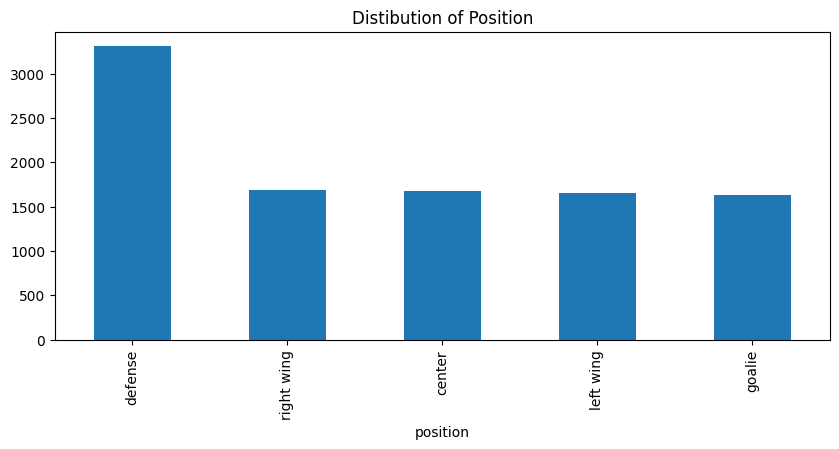

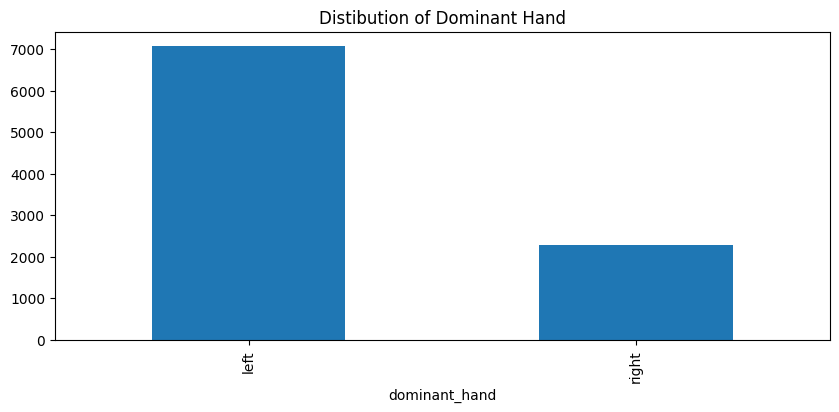

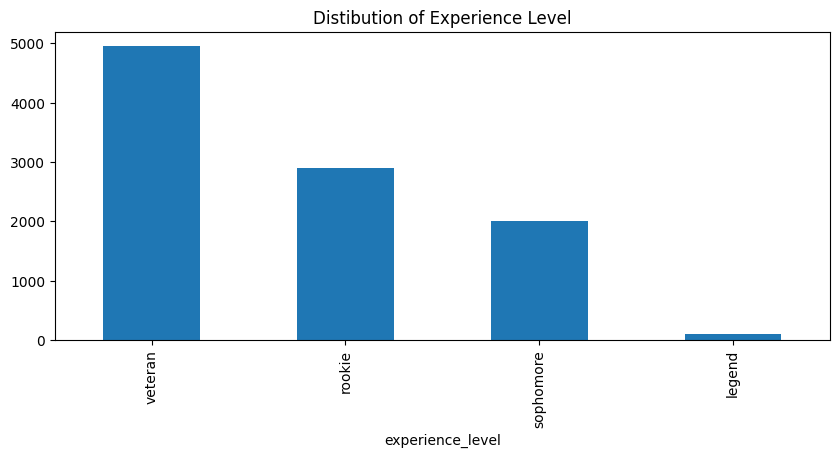

In [106]:
scouting_columns = [
    "position",
    "dominant_hand",
    "experience_level"
]

for col in scouting_columns:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distibution of {col.replace('_', ' ').title()}")
        plt.show()

In [107]:
display(moms.head())
moms.isnull().sum().sort_values(ascending=False)

,first_name,last_name,age,birth_city,school_grade,years_in_usa,eye_color,stuffed_animal_name,favourite_board_game,personal_notes,favourite_child_info,favourite_tv_show,favourite_food
0,Edward,Battey,21.0,Stockholm,3.51,0.0,HAZEL,Dawn,Attack!,None,"I have no favourite child, I love them all equ...",,
1,Winifred,Bien,19.0,Oslo,3.02,2.0,HAZEL,John,Dungeons & Dragons,gently reflective in life,"I have no favourite child, I love them all equ...",,
2,None,None,NaN,None,NaN,NaN,None,None,None,None,"I have no favourite child, I love them all equ...",,
3,Carolyn,Gaudino,27.0,kosice,2.61,0.0,brown,Jeff,Dungeons & Dragons,None,"I have no favourite child, I love them all equ...",,
4,Christopher,Goode,26.0,Budapest,2.60,3.0,brown,Irma,Dungeons & Dragons,gently introspective most days,"I have no favourite child, I love them all equ...",,


personal_notes          2527
favourite_board_game     431
eye_color                297
last_name                 37
first_name                37
school_grade              37
birth_city                37
age                       37
years_in_usa              37
stuffed_animal_name       37
favourite_child_info       0
favourite_tv_show          0
favourite_food             0
dtype: int64

In [108]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

medical_information           8518
scout_notes                   1038
dominant_hand                  651
fitness_level                  467
number_of_previous_teams       206
contracts_signed               122
shot_speed                      37
high_danger_shots               37
goals                           37
assists                         37
num_of_shots                    37
penalty_kill_time               37
power_play_time                 37
power_play_goals                37
time_on_ice                     37
faceoff_win_percentage          37
puck_touches                    37
puck_recoveries                 37
puck_possession_time            37
goals_against_total             37
penality_minutes                37
shot_attempts                   37
shooting_percentage             37
low_danger_shots                37
medium_danger_shots             37
save_percentage                 37
winning_goals                   37
weight                          37
passes_completed    

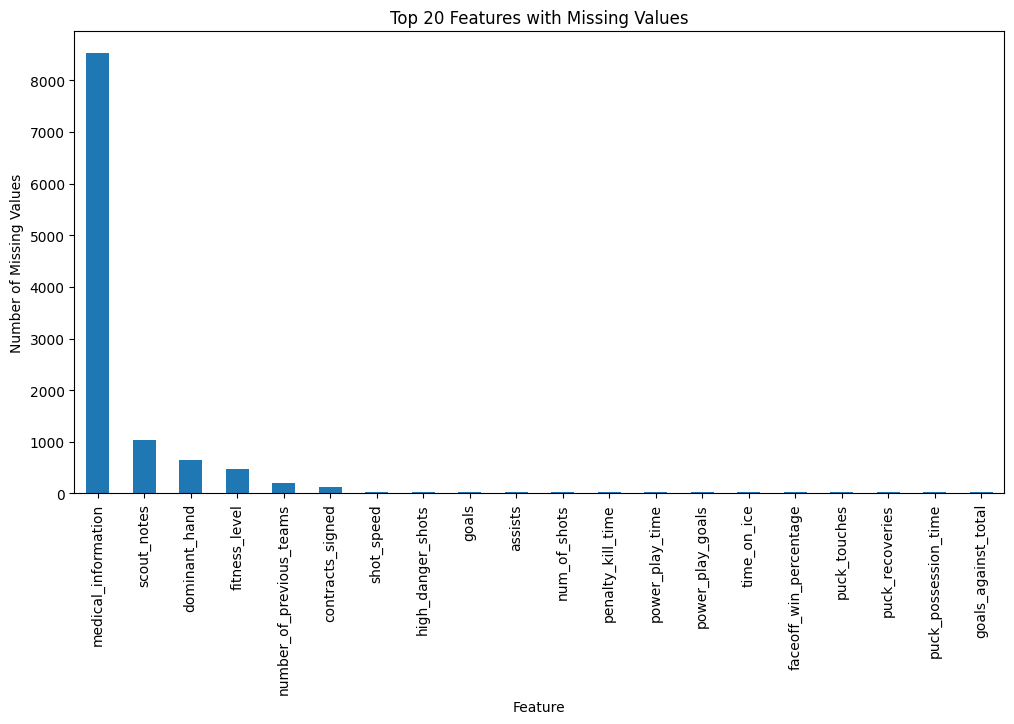

In [109]:
plt.figure(figsize=(12, 6))
missing[missing > 0].head(20).plot(kind="bar")
plt.title("Top 20 Features with Missing Values")
plt.ylabel("Number of Missing Values")
plt.xlabel("Feature")
plt.show()

In [110]:
df.describe()

,international_id,goals,assists,num_of_shots,shot_speed,shot_attempts,shooting_percentage,high_danger_shots,medium_danger_shots,low_danger_shots,...,years_played,years_pro,contracts_signed,salary,jersey_number,draft_year,number_of_previous_teams,height,weight,body_fat_percentage
count,10000.00000,9963.000000,9963.000000,9963.000000,9963.000000,9963.000000,9963.000000,9963.000000,9963.000000,9963.000000,...,9963.000000,9963.000000,9878.000000,9.963000e+03,9963.000000,9963.000000,9794.000000,9963.000000,9963.000000,9963.000000
mean,5000.50000,90.396467,169.609355,447.893606,92.035790,467.688447,28.447780,147.866606,165.001807,154.820034,...,6.093747,4.971996,4.117331,1.355140e+06,34.747265,2017.276925,10.062181,170.719972,82.891588,23.902588
std,2886.89568,30.258722,33.403953,34.892880,22.998729,25.945704,15.996095,13.383701,23.313373,22.890100,...,3.778478,2.969043,2.517389,1.226619e+06,31.341395,9.668200,4.054554,13.572074,6.095039,2.955568
min,1.00000,16.000000,68.000000,46.000000,43.282200,376.000000,0.299900,97.000000,95.000000,89.000000,...,0.000000,0.000000,1.000000,1.249963e+05,1.000000,1850.000000,0.000000,131.649400,71.681700,13.990000
25%,2500.75000,69.000000,146.000000,435.000000,76.125000,450.000000,15.933500,139.000000,148.000000,137.000000,...,3.000000,3.000000,2.000000,5.823173e+05,7.000000,2015.000000,6.000000,163.195100,78.161900,21.850000
50%,5000.50000,87.000000,167.000000,450.000000,85.340400,467.000000,26.516700,148.000000,167.000000,152.000000,...,7.000000,6.000000,4.000000,9.835806e+05,24.000000,2018.000000,11.000000,170.212700,81.731800,23.720000
75%,7500.25000,108.000000,191.000000,464.000000,103.113050,485.000000,38.665400,157.000000,182.000000,170.000000,...,9.000000,7.000000,6.000000,1.697548e+06,62.000000,2021.000000,14.000000,177.000450,86.459300,25.700000
max,10000.00000,265.000000,342.000000,535.000000,192.852200,582.000000,88.858200,201.000000,239.000000,238.000000,...,15.000000,10.000000,17.000000,1.831961e+07,99.000000,2025.000000,15.000000,309.000000,117.958900,37.340000


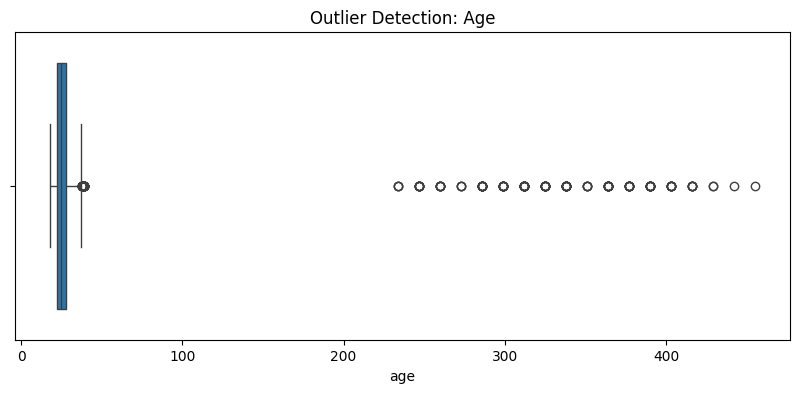

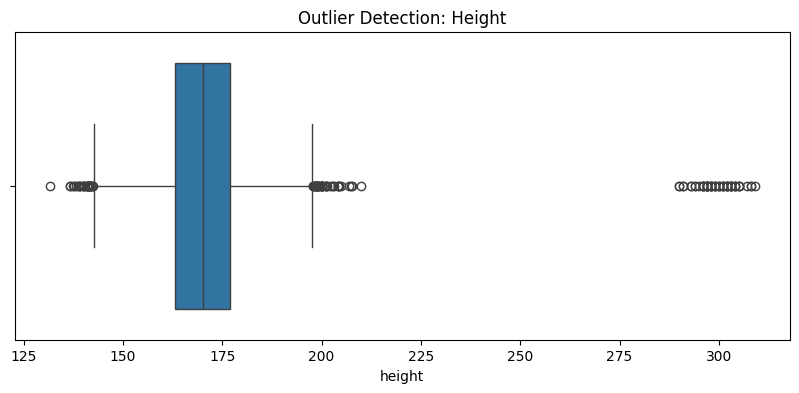

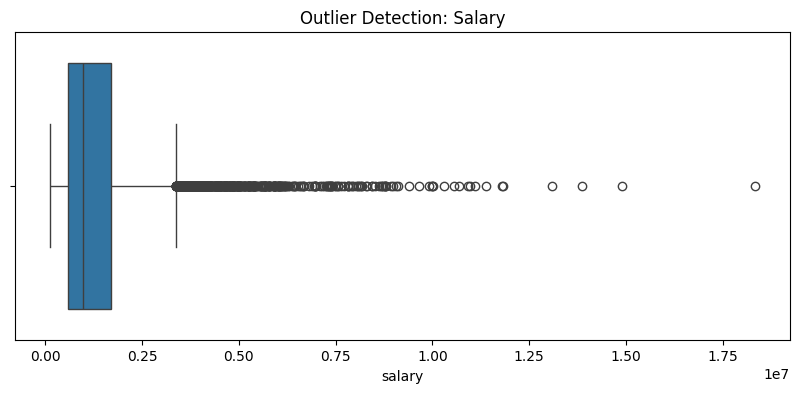

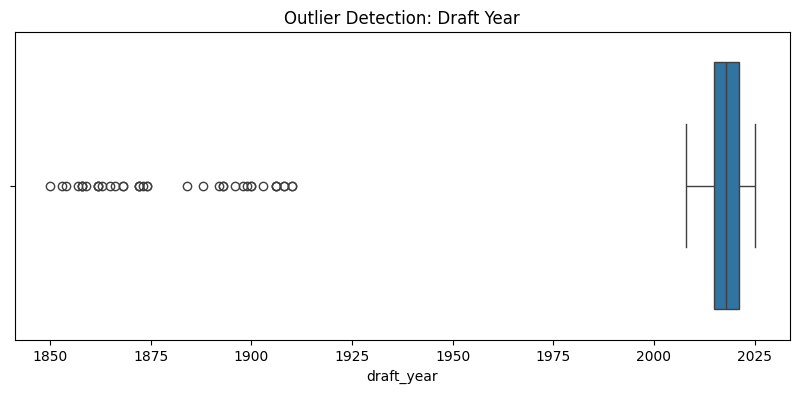

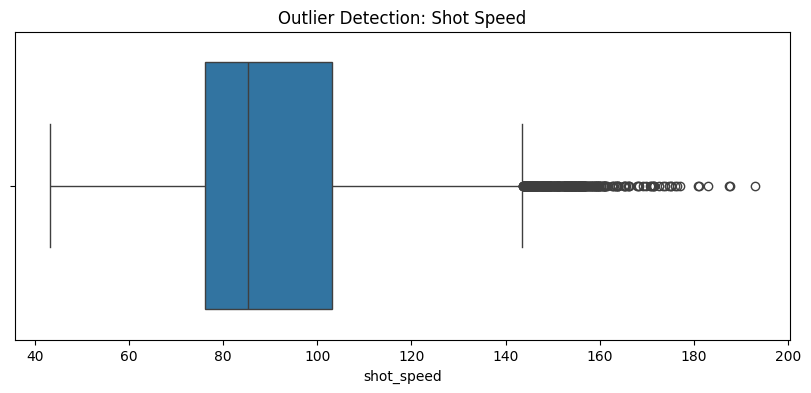

In [111]:
outlier_columns = [
    "age",
    "height",
    "salary",
    "draft_year",
    "shot_speed",
]

outlier_columns = [col for col in outlier_columns if col in df.columns]

for col in outlier_columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection: {col.replace('_', ' ').title()}")
    plt.show()

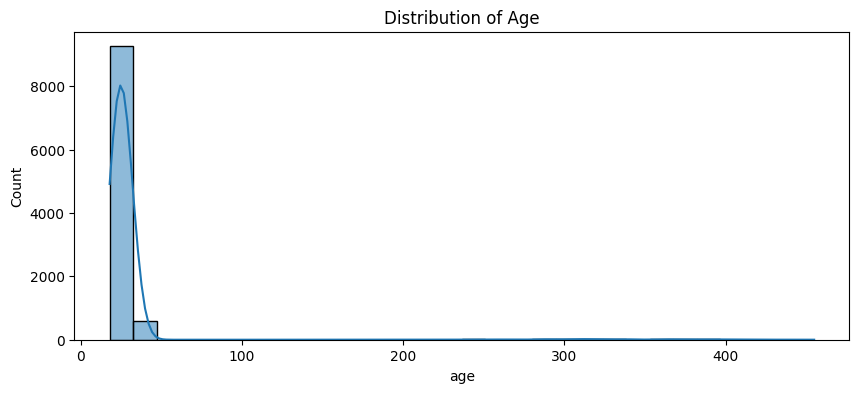

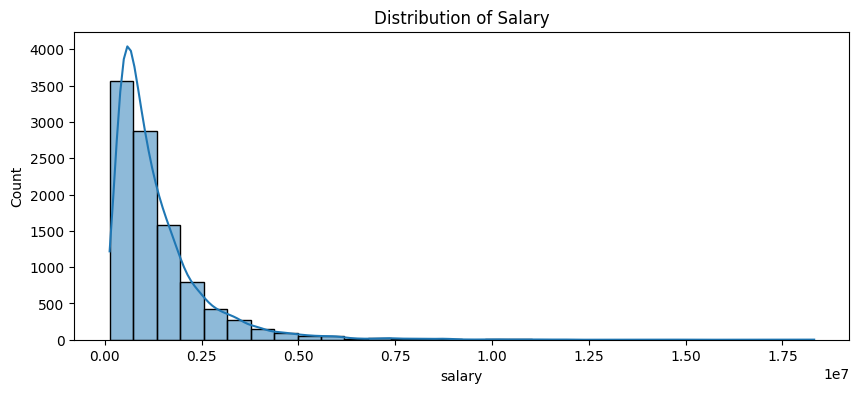

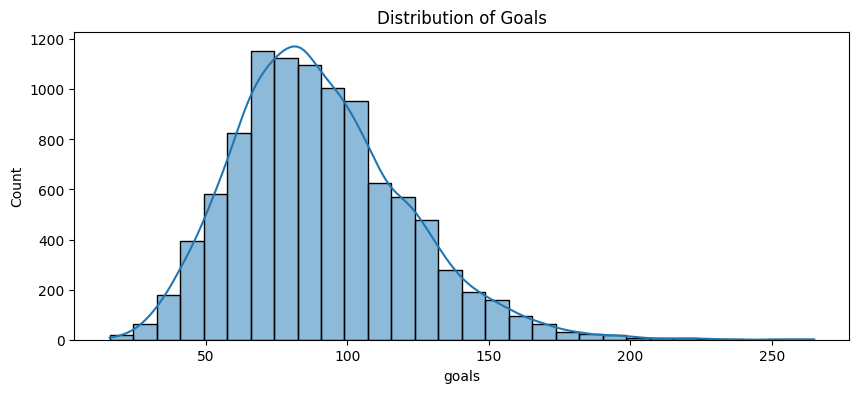

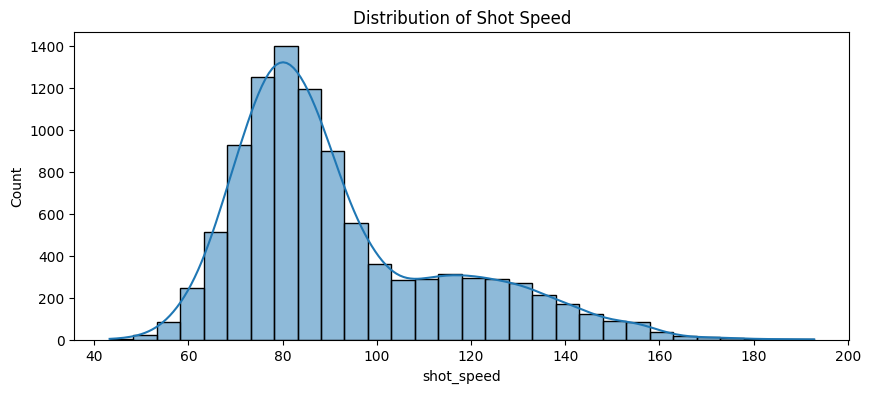

In [112]:
distribution_columns = [
    "age",
    "salary",
    "goals",
    "shot_speed",
]

distribution_columns = [col for col in distribution_columns if col in df.columns]

for col in distribution_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.show()

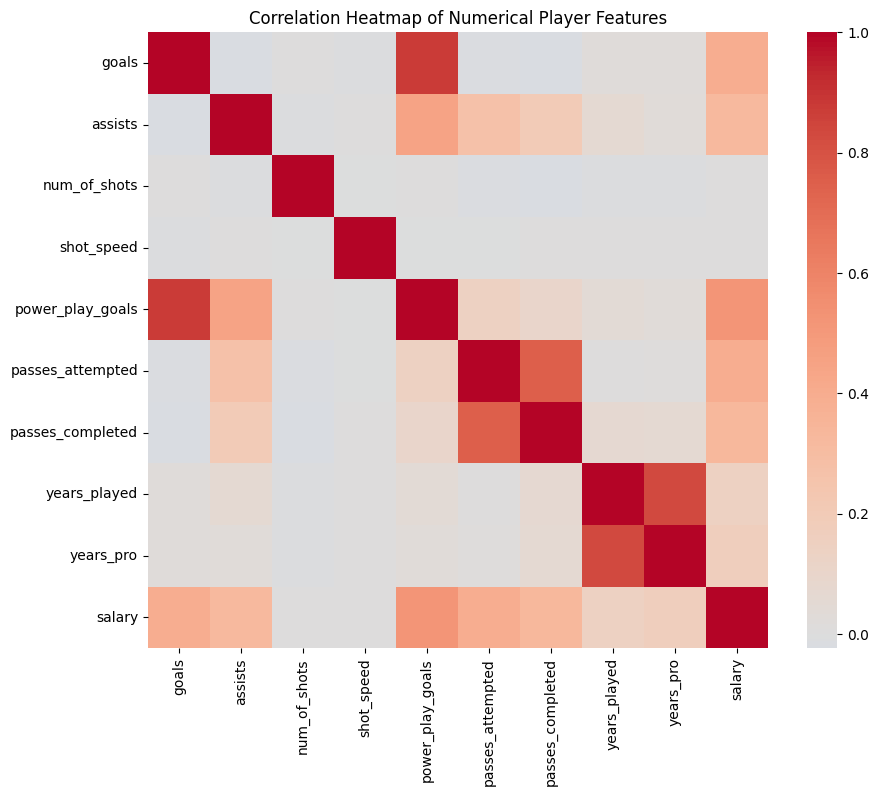

In [113]:
relationship_columns = [
    "goals",
    "assists",
    "num_of_shots",
    "shot_speed",
    "power_play_goals",
    "passes_attempted",
    "passes_completed",
    "years_played",
    "years_pro",
    "salary"
]

relationship_columns = [col for col in relationship_columns if col in df.columns]

corr = df[relationship_columns].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Player Features")
plt.show()

In [114]:
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

goals             power_play_goals    0.878114
power_play_goals  goals               0.878114
years_played      years_pro           0.831689
years_pro         years_played        0.831689
passes_attempted  passes_completed    0.748265
passes_completed  passes_attempted    0.748265
salary            power_play_goals    0.521279
power_play_goals  salary              0.521279
                  assists             0.447156
assists           power_play_goals    0.447156
dtype: float64

# Phase 2

In [115]:
print(df.isnull().sum().sort_values(ascending=False))

medical_information           8518
scout_notes                   1038
dominant_hand                  651
fitness_level                  467
number_of_previous_teams       206
contracts_signed               122
shot_speed                      37
high_danger_shots               37
goals                           37
assists                         37
num_of_shots                    37
penalty_kill_time               37
power_play_time                 37
power_play_goals                37
time_on_ice                     37
faceoff_win_percentage          37
puck_touches                    37
puck_recoveries                 37
puck_possession_time            37
goals_against_total             37
penality_minutes                37
shot_attempts                   37
shooting_percentage             37
low_danger_shots                37
medium_danger_shots             37
save_percentage                 37
winning_goals                   37
weight                          37
passes_completed    

In [116]:

missing_links = missing_links_raw[[
    "international_id", 
    "training_pct", 
    "uses_tinted_visor", 
    "pass_drill_success_pct", 
    "avg_shoot_speed", 
    "shot_power_score", 
    "travel_fatigue_score", 
    "selection_probability"]]

missing_links.head()

,international_id,training_pct,uses_tinted_visor,pass_drill_success_pct,avg_shoot_speed,shot_power_score,travel_fatigue_score,selection_probability
0,1,64.807142,0,47.28,91.74,62.09,-5.41,0.814629
1,2,60.258916,1,71.46,94.18,65.02,-1.56,0.898043
2,3,29.876669,0,78.72,80.46,48.55,-1.57,0.472083
3,4,41.177986,1,81.00,90.87,61.04,-3.19,0.262367
4,5,67.248762,0,45.84,81.37,49.64,-0.76,0.951979


In [117]:
missing_links["training_pct"] = missing_links["training_pct"].fillna(0)
missing_links["shot_power_score"]=missing_links["shot_power_score"].fillna(0)

missing_links.head(10)

C:\Users\kilia\AppData\Local\Temp\ipykernel_5136\2215846607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_links["training_pct"] = missing_links["training_pct"].fillna(0)
C:\Users\kilia\AppData\Local\Temp\ipykernel_5136\2215846607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_links["shot_power_score"]=missing_links["shot_power_score"].fillna(0)


,international_id,training_pct,uses_tinted_visor,pass_drill_success_pct,avg_shoot_speed,shot_power_score,travel_fatigue_score,selection_probability
0,1,64.807142,0,47.28,91.74,62.09,-5.41,0.814629
1,2,60.258916,1,71.46,94.18,65.02,-1.56,0.898043
2,3,29.876669,0,78.72,80.46,48.55,-1.57,0.472083
3,4,41.177986,1,81.00,90.87,61.04,-3.19,0.262367
4,5,67.248762,0,45.84,81.37,49.64,-0.76,0.951979
5,6,50.494823,0,66.28,94.08,64.90,-1.12,0.927759
6,7,0.000000,0,67.59,84.84,53.81,-6.68,0.943495
7,8,28.662456,0,35.69,78.15,45.78,-1.81,0.431149
8,9,27.326114,0,63.45,73.08,39.70,-4.77,0.419445
9,10,50.933166,0,61.45,82.97,51.56,-3.82,0.343240


In [118]:
df = df.merge(missing_links, on="international_id", how="left")

In [119]:
target = "selection_probability"

In [120]:
#df.to_excel("merged_data.xlsx", index=False)

In [121]:
drop_columns=[
    'international_id',
    'medical_id',
    'first_name',
    'last_name',
    'scout_notes',
    'medical_information',
    'physician_signature',
    'return_date'
]

df = df.drop(columns=drop_columns)

df.head()

,goals,assists,num_of_shots,shot_speed,shot_attempts,shooting_percentage,high_danger_shots,medium_danger_shots,low_danger_shots,save_percentage,...,body_fat_percentage,fitness_level,sprint_time,training_pct,uses_tinted_visor,pass_drill_success_pct,avg_shoot_speed,shot_power_score,travel_fatigue_score,selection_probability
0,166.0,244.0,461.0,130.6172,480.0,12.6758,158.0,185.0,137.0,63.9321,...,27.31,poor,4.2241,78.518008,0,72.06,79.35,47.22,-0.82,0.021602
1,98.0,166.0,459.0,76.4679,490.0,10.1533,142.0,186.0,162.0,55.3581,...,23.65,excellent,3.786,53.232519,0,73.81,81.23,49.48,-4.22,0.764169
2,87.0,167.0,439.0,82.1817,449.0,33.3924,134.0,165.0,150.0,80.0563,...,25.84,average,4.6467,40.257333,1,33.91,85.23,54.28,-1.10,0.546626
3,93.0,155.0,447.0,73.0825,447.0,30.7875,141.0,136.0,170.0,72.6164,...,25.98,average,4.2762,53.880459,0,91.73,80.98,49.18,-3.18,0.084564
4,104.0,169.0,496.0,75.9673,503.0,42.2507,188.0,163.0,152.0,70.3253,...,29.01,good,4.3509,58.823437,1,36.68,82.42,50.90,-1.46,0.537052


In [122]:
cat_cols=[
    'gender',
    'birth_city',
    'nationality',
    'position',
    'dominant_hand',
    'experience_level',
    'captain',
    'won_championship',
    'fitness_level',
    'uses_tinted_visor'
]


In [123]:
cat_cols=[col for col in cat_cols if col in df.columns]

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

num_cols=df.select_dtypes(include=['int64', 'float64']).columns
num_cols=num_cols.drop('selection_probability', errors='ignore')

df[num_cols]=df[num_cols].fillna(df[num_cols].median())

df=pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(df.isnull().sum().sum())

C:\Users\kilia\AppData\Local\Temp\ipykernel_5136\3991740243.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]=df[col].fillna(df[col].mode()[0])


111


In [124]:
df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending=False)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype=='object':
            df[col]=df[col].fillna(df[col].mode()[0])
        else:
            df[col]=df[col].fillna(df[col].median())

print(df.isnull().sum().sum())

0


C:\Users\kilia\AppData\Local\Temp\ipykernel_5136\3416015292.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]=df[col].fillna(df[col].mode()[0])


In [125]:
#df.to_excel("merged_data_finak.xlsx", index=False)

In [126]:
print(df.columns[-10:])
print('selection_probability' in df.columns)

Index(['experience_level_rookie', 'experience_level_sophomore',
       'experience_level_veteran', 'captain_True', 'won_championship_True',
       'fitness_level_elite', 'fitness_level_excellent', 'fitness_level_good',
       'fitness_level_poor', 'uses_tinted_visor_1'],
      dtype='object')
True


In [127]:
X=df.drop('selection_probability', axis=1)
y=df['selection_probability']

In [128]:
y.describe()

count    10000.000000
mean         0.498211
std          0.304919
min          0.002703
25%          0.217504
50%          0.494064
75%          0.779518
max          0.999250
Name: selection_probability, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [130]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7500, 339)
X_test: (2500, 339)
y_train: (7500,)
y_test: (2500,)


In [131]:
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
baseline_preds = baseline_mean.predict(X_test)

In [132]:
mae = mean_absolute_error(y_test, baseline_preds)
rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
r2 = r2_score(y_test, baseline_preds)

print("Baseline Mean")
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

Baseline Mean
MAE: 0.2701668147573333
RMSE: 0.30581350563837023
R^2: -2.996018169110215e-07


In [133]:
random_forest = RandomForestRegressor(n_estimators=50, random_state=10)

In [134]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

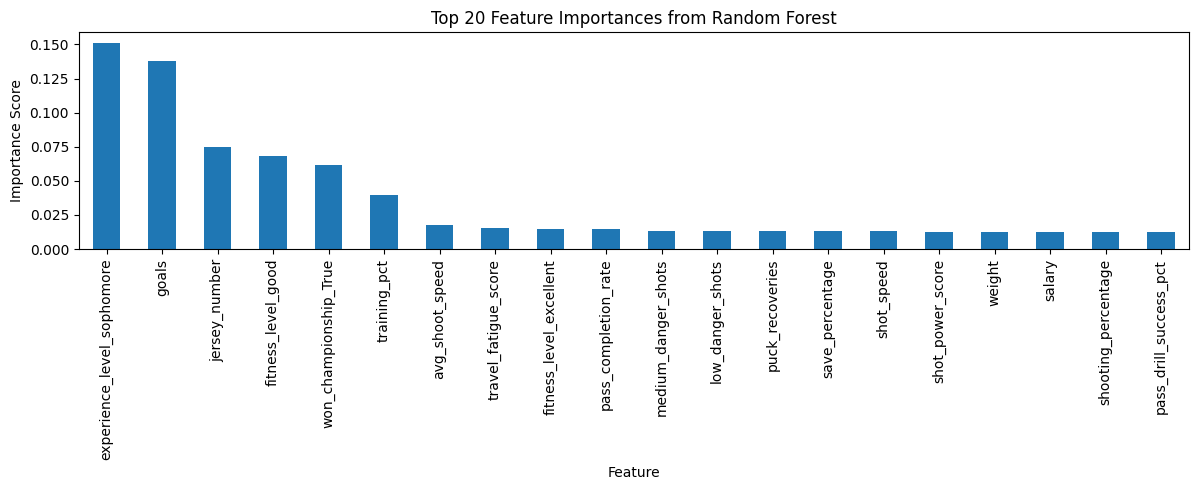

In [135]:
_rf_selector = RandomForestRegressor(n_estimators=50, random_state=10)
_rf_selector.fit(X_train, y_train)
importances = pd.Series(_rf_selector.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances from Random Forest")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

In [136]:
threshold = importances.mean()
selected_features = importances[importances >= threshold].index.to_list()

print(f"Selected Features above threshold: ({threshold:.4f}): {len(selected_features)}")
print(selected_features)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Selected Features above threshold: (0.0029): 47
['experience_level_sophomore', 'goals', 'jersey_number', 'fitness_level_good', 'won_championship_True', 'training_pct', 'avg_shoot_speed', 'travel_fatigue_score', 'fitness_level_excellent', 'pass_completion_rate', 'medium_danger_shots', 'low_danger_shots', 'puck_recoveries', 'save_percentage', 'shot_speed', 'shot_power_score', 'weight', 'salary', 'shooting_percentage', 'pass_drill_success_pct', 'sprint_time', 'power_play_time', 'power_play_goals', 'time_on_ice', 'body_fat_percentage', 'faceoff_win_percentage', 'penalty_kill_time', 'time_between_penalties', 'penality_minutes', 'passes_completed', 'height', 'shoe_size', 'shot_attempts', 'high_danger_shots', 'num_of_shots', 'passes_attempted', 'assists', 'puck_touches', 'games_missed_due_to_injury', 'puck_possession_time', 'winning_goals', 'number_of_previous_teams', 'contracts_signed', 'years_played', 'fitness_level_poor', 'draft_year', 'years_pro']


In [137]:
def evaluate(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R^2": round(r2_score(y_true, y_pred), 4)
    }
results = []

In [138]:
baseline_mean_selected = DummyRegressor(strategy="mean")
baseline_mean_selected.fit(X_train_selected, y_train)
results.append(evaluate("Baseline Mean (Selected)", y_test, baseline_mean_selected.predict(X_test_selected)))

print("Baseline A, Mean")
print(results[-1])

Baseline A, Mean
{'model': 'Baseline Mean (Selected)', 'MAE': 0.2702, 'RMSE': np.float64(0.3058), 'R^2': -0.0}


In [ ]:
baseline_median = DummyRegressor(strategy="median")
baseline_median.fit(X_train_selected, y_train)
results.append(evaluate("Baseline Median (Selected)", y_test, baseline_median.predict(X_test_selected)))

print("Baseline B, Median")
print(results[-1])

Baseline A, Median
{'model': 'Baseline Median (Selected)', 'MAE': 0.2702, 'RMSE': np.float64(0.3058), 'R^2': -0.0}


In [140]:
random_forest.fit(X_train_selected, y_train)
rf_preds = random_forest.predict(X_test_selected)
results.append(evaluate("Random Forest (Selected)", y_test, rf_preds))
print("Random Forest (Selected)")
print(results[-1])


Random Forest (Selected)
{'model': 'Random Forest (Selected)', 'MAE': 0.1806, 'RMSE': np.float64(0.2222), 'R^2': 0.4722}


In [141]:
grad_boost = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=4, random_state=10)
grad_boost.fit(X_train_selected, y_train)
gb_preds = grad_boost.predict(X_test_selected)
results.append(evaluate("Gradient Boosting (Selected)", y_test, gb_preds))
print("Gradient Boosting (Selected)")
print(results[-1])


Gradient Boosting (Selected)
{'model': 'Gradient Boosting (Selected)', 'MAE': 0.191, 'RMSE': np.float64(0.2231), 'R^2': 0.4679}


In [142]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train_selected, y_train)
ridge_preds = ridge_pipeline.predict(X_test_selected)
results.append(evaluate("Ridge Regression (Selected)", y_test, ridge_preds))
print("Ridge Regression (Selected)")
print(results[-1])

Ridge Regression (Selected)
{'model': 'Ridge Regression (Selected)', 'MAE': 0.2097, 'RMSE': np.float64(0.2507), 'R^2': 0.3279}


In [143]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R^2", ascending=False).reset_index(drop=True)
print(results_df)

                          model     MAE    RMSE     R^2
0      Random Forest (Selected)  0.1806  0.2222  0.4722
1  Gradient Boosting (Selected)  0.1910  0.2231  0.4679
2   Ridge Regression (Selected)  0.2097  0.2507  0.3279
3      Baseline Mean (Selected)  0.2702  0.3058 -0.0000
4    Baseline Median (Selected)  0.2702  0.3058 -0.0000


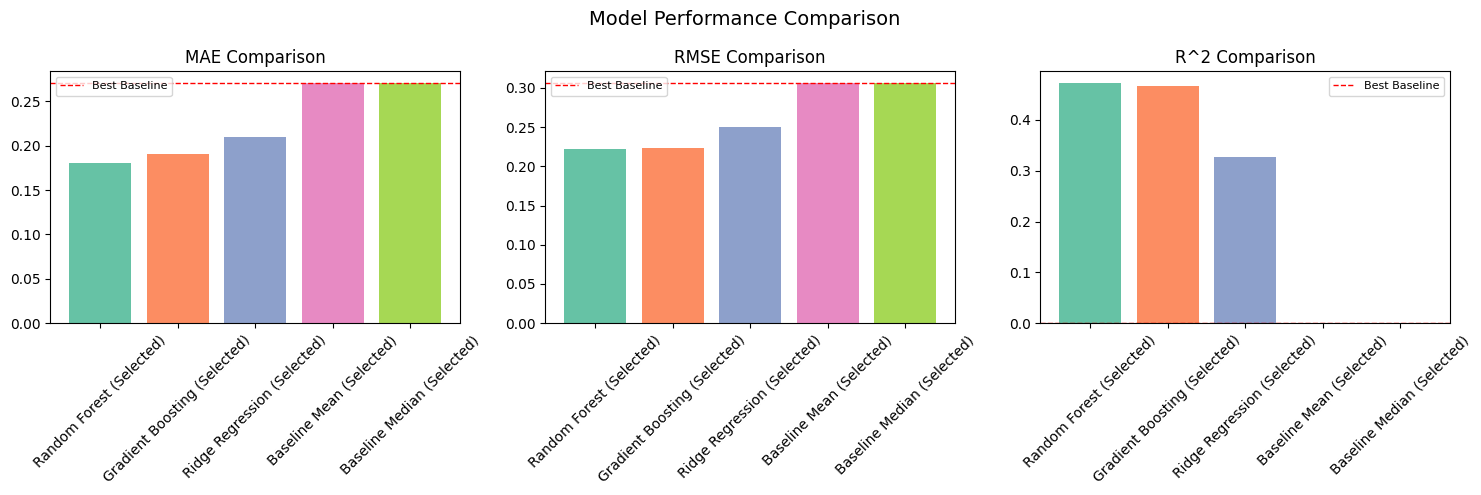

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes,["MAE", "RMSE", "R^2"]):
    colors = sns.color_palette("Set2", n_colors=len(results_df))
    ax.bar(results_df["model"], results_df[metric], color=colors)
    ax.set_title(f"{metric} Comparison")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(
        results_df[results_df["model"].str.startswith("Baseline")][metric].max(),
        color="red", linestyle="--", linewidth=1,
        label="Best Baseline"
    )
    ax.legend(fontsize=8)

plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()
    

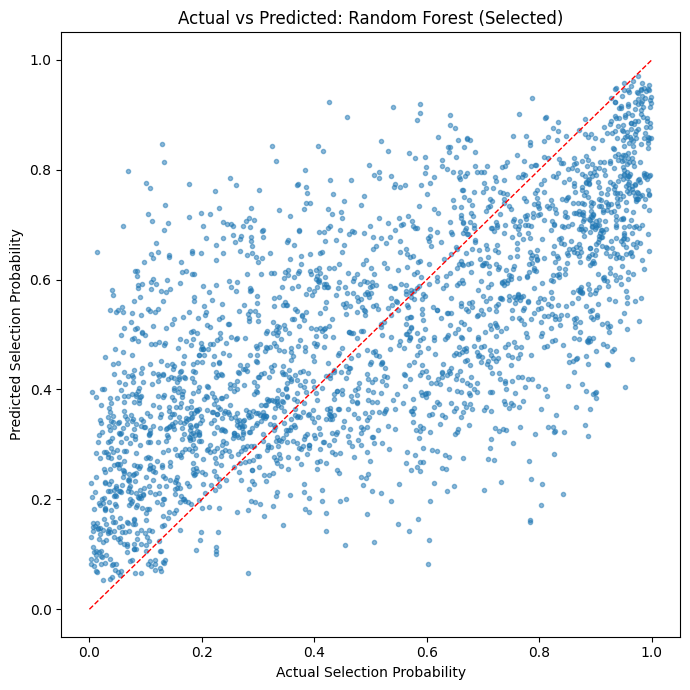

In [145]:
best_model_name = results_df.iloc[0]["model"]
best_preds_map = {
    "Random Forest (Selected)": rf_preds,
    "Gradient Boosting (Selected)": gb_preds,
    "Ridge Regression (Selected)": ridge_preds
}
best_preds = best_preds_map.get(best_model_name, rf_preds)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.5, s=9)
plt.plot([0, 1], [0, 1], "r--", linewidth=1)
plt.xlabel("Actual Selection Probability")
plt.ylabel("Predicted Selection Probability")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.tight_layout()
plt.show()

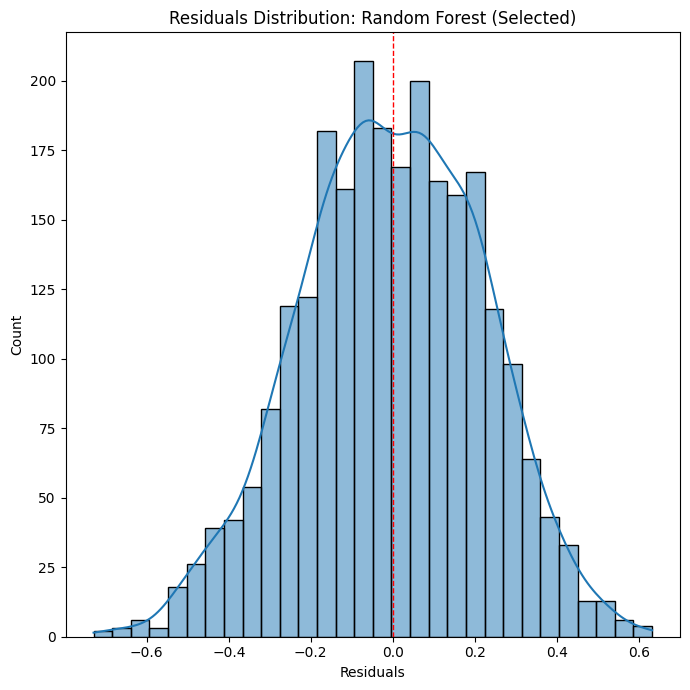

In [146]:
residuals = y_test - best_preds

plt.figure(figsize=(7, 7))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Residuals")
plt.title(f"Residuals Distribution: {best_model_name}")
plt.tight_layout()
plt.show()